## Overview
In this notebook, we will run DCON on a Solovev ideal example equilibrium and plot the results

In [7]:
# Load in necessary packages
using Pkg
using LinearAlgebra
using HDF5
using Plots
using LaTeXStrings

## Run the code
We will run the main DCON code using the inputs specified in `dcon.toml`, `equil.toml`, and `vac.in`. We output the `euler.h5` file, which is a Julia version of the `euler.bin` file.

In [3]:
# Run DCON in Julia
Pkg.activate("../..")
using JPEC
JPEC.DCON.Main("./") # "./" tells us to obtain inputs and direct outputs to our current folder

  Activating project at `~/code/JPEC`


DCON START
----------------------------------


┌ Info: Forcing hamada coordinate jacobian exponents: power_*
└ @ JPEC.Equilibrium /home/aspire1019/code/JPEC/src/Equilibrium/EquilibriumTypes.jl:58


Equilibrium file: TKMKR_D3Dlike_default_Hmode.geqdsk
--> Processing EFIT g-file: TKMKR_D3Dlike_default_Hmode.geqdsk
--> Parsed from header: nw=129, nh=129
   Magnetic axis found at R = 1.89620, Z = -0.01384
   Inboard separatrix found at R = 1.143209075944761.
   Outboard separatrix found at R = 2.344183349547248.


┌ Info: Setting psilim via dmlim: initial qlim = 11.63241067525468, dmlim = 0.2
└ @ JPEC.DCON /home/aspire1019/code/JPEC/src/DCON/Sing.jl:106


...

┌ Warning: W inverse matrix was non-Hermitian beyond tolerance at 40 integration step(s)
└ @ JPEC.DCON /home/aspire1019/code/JPEC/src/DCON/FixedBoundaryStability.jl:33


Computing free boundary energies


┌ Info: Using no wall
└ @ JPEC.Vacuum /home/aspire1019/code/JPEC/src/Vacuum/VacuumStructs.jl:277


Least Stable Eigenmode Energies:
  Plasma = -5.543e+00 +2.803e-07i
  Vacuum = +5.540e+00 -3.741e-04i
  Total  = -2.765e-03 -3.738e-04i
Free-boundary mode unstable for n = 1.
Writing saved data to euler.h5
----------------------------------
Run time: 1.511e+01 seconds
Normal termination.


(ctrl = JPEC.DCON.DconControl(true, false, true, true, true, true, false, 512, 0, 1, 1, 8, 16, 0, 1.0, 9223372036854775807, -1, 1.0e-6, 1.0e-7, 0.01, 10000.0, 4000, 100, 0.0001, false, true, 0.2, 2, 1000.0, false, false, 1.0, 1.0, 0, true, true, true, true, false, 0.1, 50.0, 1.02, false, 1.0, 20, true, 1, 1, false, false, true, "euler.h5", true), equil = JPEC.Equilibrium.PlasmaEquilibrium(JPEC.Equilibrium.EquilibriumConfig(JPEC.Equilibrium.EquilibriumControl("efit", "TKMKR_D3Dlike_default_Hmode.geqdsk", "hamada", 0, 0, 0, "ldp", 0.0001, 0.993, 128, 256, 0, 1.0e-7, false, false, true), JPEC.Equilibrium.EquilibriumOutput(false, false, false, false, true, false, false, false)), JPEC.Equilibrium.EquilibriumParameters(nothing, nothing, nothing, [2.3419424072346526, 1.2476924700862937], [-0.7659556221182695, -0.7659556221182705], [1.5773454456974612, 1.5773454456974634], [-0.7659556221182695, -0.7659556221182705], 0.081547094724, 1.7206253347714164, 2.074748411686715, 2.074748411686715, 11.6

## Analyze Outputs
We will now analyze the outputs of the run, the most important of which are located in the `euler.h5` output file

In [8]:
# Read in the euler.h5 data
eh5 = h5open("euler.h5", "r")
mlow = read(eh5["info/mlow"])
xi_psi = read(eh5["integration/xi_psi"])
psifac = read(eh5["integration/psi"])
wt = read(eh5["vacuum/wt"])
crit = read(eh5["integration/crit"])
psio = read(eh5["equil/psio"])
et = read(eh5["vacuum/et"])
close(eh5)

# scale energy eigenvector matrices
chi1 = 2π*psio
wt = wt*(chi1*1e-3)
println("Done reading euler.h5")

Done reading euler.h5


### Plot comparison of xi_psi for a few poloidal mode numbers

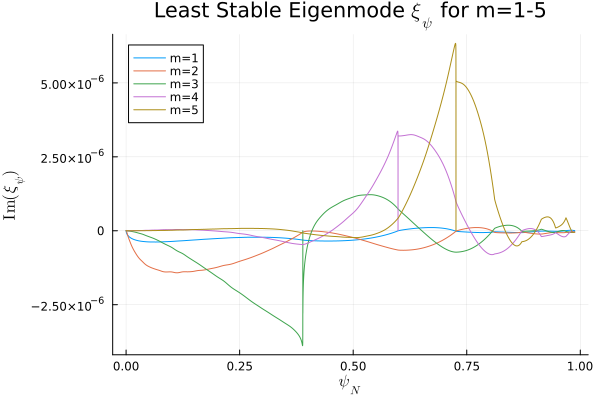

In [9]:
p = plot()
for m in 1:5
    plot!(psifac, imag.(xi_psi[m - mlow + 1, 1, :]), label="m=$m")
end
xlabel!(L"\psi_N")
ylabel!(L"\mathrm{Im}(\xi_\psi)")
title!("Least Stable Eigenmode " * L"\xi_\psi" * " for " * "m=1-5")

### Compare the eigenvectors and eigenvalues of each DCON energy matrix eigenmode
This is analagous to the DCON summary plot creating by OMFIT GPEC

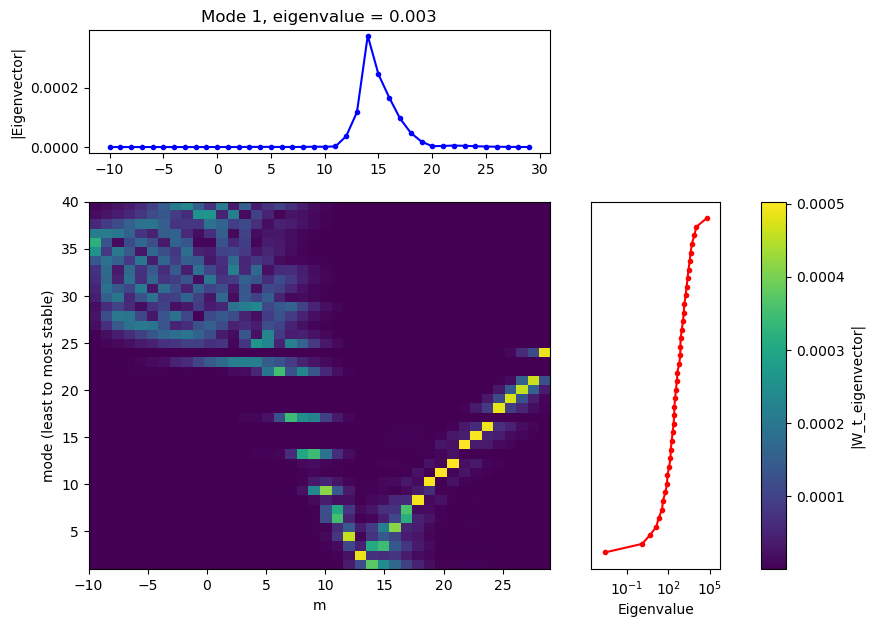

In [11]:
# I got tired of trying to get the Plots version of this to work, so here's a PyPlot version
using PyPlot

# Axes labels
xlabel = "m"
ylabel = "mode (least to most stable)"

yvals = 1:size(wt, 2)
xvals = (1:size(wt, 1)) .+ (mlow + 1)

# Create figure and grid layout
fig = figure(figsize=(9, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[0.25, 0.75], width_ratios=[0.75, 0.21, 0.04])

# Top-left: Eigenvector amplitude
ax0 = fig.add_subplot(gs[1, 1])
ax0.plot(xvals, abs.(wt[:, 1]), color="blue", marker="o", markersize=3)
ax0.set_ylabel("|Eigenvector|")
ax0.set_xlabel("")
ax0.set_title("Mode 1, eigenvalue = $(round(abs(et[1]), digits=3))")

# Bottom-left: Heatmap
ax1 = fig.add_subplot(gs[2, 1])
im = ax1.imshow(abs.(wt') , aspect="auto", origin="lower",
                cmap="viridis", extent=[xvals[1], xvals[end], yvals[1], yvals[end]])
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel)

# Right middle: Eigenvalue amplitude
ax2 = fig.add_subplot(gs[2, 2])
ax2.plot(abs.(et), yvals, color="red", marker="o", markersize=3)
ax2.set_xlabel("Eigenvalue")
ax2.set_xscale("log")
ax2.set_xlim(0.1 * minimum(abs.(et)), 10 * maximum(abs.(et)))
ax2.set_yticks([])

# Colorbar (bottom right)
cax = fig.add_subplot(gs[2, 3])
cb = fig.colorbar(im, cax=cax)
cb.set_label("|W_t_eigenvector|")

# Display and save figure
display(fig)

### Plot crit (the smallest eigenvalue of $W^{-1}$) versus $\Psi$
If crit changes signs during integration, we know we are unstable to an ideal fixed-boundary instability.

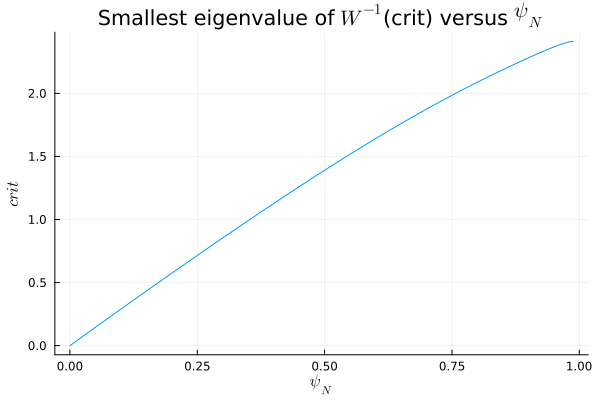

In [12]:
# Plot crit vs psi
p = plot(psifac, crit, legend=false)
xlabel!(L"\psi_N")
ylabel!(L"crit")
title!("Smallest eigenvalue of " * L"W^{-1}" * "(crit) versus " * L"\psi_N")